## Maximizing Revenue For Taxi Cab Drivers Through Payment Type Analysis

# Problem Statement
The objective of this project is to determine whether the payment method (Card or Cash) has a significant relationship with taxi fare amounts. Using exploratory data analysis, hypothesis testing, and linear regression, the project analyzes fare patterns to identify factors that can help improve revenue optimization and support data-driven business decisions.


# Objective
This project's main goal is to run an A/B test to examine the relationship between the total fare and the method of payment. we use python Hypothesis testing and descriptive statistics to extract usefull information that can help taxi drivers to genrate more cash. In particular we want to find out if there is a big difference in the fares for those who pay with credit cards versus those who pay with cash.


# Research Question
Is there a relationship between total fare amount and payment type and can we nudge customer towards payment methods that generate higher revenue for drivers, without negatively impacting customer experience ?


# Imports 
We start by importaing all the essential Python libraries for data analysis, visualization, and hypothesis testing.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as st
import warnings 
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("yellow_tripdata_2020-01 (1).csv")

In [3]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
0,1.0,2020-01-01 00:28:15,2020-01-01 00:33:03,1.0,1.2,1.0,N,238,239,1.0,6.0,3.0,0.5,1.47,0.0,0.3,11.27,2.5
1,1.0,2020-01-01 00:35:39,2020-01-01 00:43:04,1.0,1.2,1.0,N,239,238,1.0,7.0,3.0,0.5,1.50,0.0,0.3,12.30,2.5
2,1.0,2020-01-01 00:47:41,2020-01-01 00:53:52,1.0,0.6,1.0,N,238,238,1.0,6.0,3.0,0.5,1.00,0.0,0.3,10.80,2.5
3,1.0,2020-01-01 00:55:23,2020-01-01 01:00:14,1.0,0.8,1.0,N,238,151,1.0,5.5,0.5,0.5,1.36,0.0,0.3,8.16,0.0
4,2.0,2020-01-01 00:01:58,2020-01-01 00:04:16,1.0,0.0,1.0,N,193,193,2.0,3.5,0.5,0.5,0.00,0.0,0.3,4.80,0.0


# Exploratory Data Analysis

In [4]:
df.shape

(6405008, 18)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6405008 entries, 0 to 6405007
Data columns (total 18 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   VendorID               float64
 1   tpep_pickup_datetime   object 
 2   tpep_dropoff_datetime  object 
 3   passenger_count        float64
 4   trip_distance          float64
 5   RatecodeID             float64
 6   store_and_fwd_flag     object 
 7   PULocationID           int64  
 8   DOLocationID           int64  
 9   payment_type           float64
 10  fare_amount            float64
 11  extra                  float64
 12  mta_tax                float64
 13  tip_amount             float64
 14  tolls_amount           float64
 15  improvement_surcharge  float64
 16  total_amount           float64
 17  congestion_surcharge   float64
dtypes: float64(13), int64(2), object(3)
memory usage: 879.6+ MB


# DateTime Conversion

    Converting pickup and dropoff timestamps to datetime formate for time based Calculation.

In [6]:
df['tpep_pickup_datetime']=pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime']=pd.to_datetime(df['tpep_dropoff_datetime'])

In [7]:
df.dtypes

VendorID                        float64
tpep_pickup_datetime     datetime64[ns]
tpep_dropoff_datetime    datetime64[ns]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag               object
PULocationID                      int64
DOLocationID                      int64
payment_type                    float64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
dtype: object

# Trip Duration Calculation
    Calculating the trip duration in minutes from pickup and dropoff times

In [8]:
df['duration'] = df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']
df['duration'] = df['duration'].dt.total_seconds()/60

In [9]:
df['duration'].head()

0    4.800000
1    7.416667
2    6.183333
3    4.850000
4    2.300000
Name: duration, dtype: float64

# Selecting just related data
    Keeping only the requered columns for analysis passenger count, payment type, fare amount, trip distance, and duration.

In [10]:
df.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'duration'],
      dtype='object')

In [11]:
df = df[['passenger_count', 'payment_type', 'fare_amount', 'trip_distance', 'duration']]

In [12]:
df

,passenger_count,payment_type,fare_amount,trip_distance,duration
0,1.0,1.0,6.00,1.20,4.800000
1,1.0,1.0,7.00,1.20,7.416667
2,1.0,1.0,6.00,0.60,6.183333
3,1.0,1.0,5.50,0.80,4.850000
4,1.0,2.0,3.50,0.00,2.300000
...,...,...,...,...,...
6405003,NaN,NaN,17.59,3.24,31.000000
6405004,NaN,NaN,46.67,22.13,76.000000
6405005,NaN,NaN,48.85,10.51,27.833333
6405006,NaN,NaN,27.17,5.49,22.650000


# Removing Missing and Duplicate Records
    Dropping rows with null values and remove duplicate entries to ensure clean data.

In [13]:
df.isna().sum()

passenger_count    65441
payment_type       65441
fare_amount            0
trip_distance          0
duration               0
dtype: int64

In [14]:
65441/len(df)*100

1.021716132126611

Note: we have only 1.02% of null records so we are able to delete this.

In [15]:
df.dropna(inplace=True)

In [16]:
df.dtypes

passenger_count    float64
payment_type       float64
fare_amount        float64
trip_distance      float64
duration           float64
dtype: object

In [17]:
df['passenger_count'] = df['passenger_count'].astype('int64')
df['payment_type'] = df['payment_type'].astype('int64')

In [18]:
df.dtypes

passenger_count      int64
payment_type         int64
fare_amount        float64
trip_distance      float64
duration           float64
dtype: object

In [19]:
df[(df.duplicated)]

,passenger_count,payment_type,fare_amount,trip_distance,duration
2056,1,2,7.0,0.00,0.000000
2441,1,1,52.0,0.00,0.200000
2446,2,1,9.5,1.70,13.066667
2465,1,1,4.0,0.40,3.083333
3344,1,1,6.0,1.20,5.350000
...,...,...,...,...,...
6339558,1,2,8.0,1.63,8.800000
6339559,1,1,8.5,1.81,8.016667
6339560,1,2,6.5,0.98,6.900000
6339562,1,1,11.0,2.10,14.233333


In [20]:
# Check count of unique values of each columns
df.apply(lambda x: x.nunique())

passenger_count       10
payment_type           5
fare_amount         2423
trip_distance       4498
duration           11769
dtype: int64

In [21]:
# Remove duplicate
df.drop_duplicates(inplace = True)

In [22]:
df.isnull().sum()

passenger_count    0
payment_type       0
fare_amount        0
trip_distance      0
duration           0
dtype: int64

In [23]:
print(df['passenger_count'].value_counts(normalize = True))
print("__"*20)
print(df['payment_type'].value_counts(normalize = True))

passenger_count
1    0.581981
2    0.190350
3    0.066360
5    0.062937
6    0.039272
4    0.036046
0    0.023033
7    0.000009
9    0.000006
8    0.000006
Name: proportion, dtype: float64
________________________________________
payment_type
1    6.782670e-01
2    3.075731e-01
3    8.721480e-03
4    5.438084e-03
5    3.324622e-07
Name: proportion, dtype: float64


In [24]:
df = df[df['payment_type']<3]
df = df[(df['passenger_count']>0) & (df['passenger_count']<6)]

In [25]:
df['passenger_count'].value_counts(normalize = True)

passenger_count
1    0.618771
2    0.203503
3    0.071196
5    0.067902
4    0.038628
Name: proportion, dtype: float64

In [26]:
df.shape

(2780283, 5)

In [27]:
df['payment_type'].replace([1, 2], ['card', 'cash'], inplace = True)

In [28]:
print(df['payment_type'].unique())

['card' 'cash']


In [29]:
df.describe().round()

,passenger_count,fare_amount,trip_distance,duration
count,2780283.0,2780283.0,2780283.0,2780283.0
mean,2.0,18.0,5.0,24.0
std,1.0,15.0,5.0,93.0
min,1.0,-500.0,-22.0,-2770.0
25%,1.0,9.0,2.0,10.0
50%,1.0,13.0,3.0,16.0
75%,2.0,21.0,5.0,23.0
max,5.0,4265.0,263.0,8525.0


# Remove Invalid and Outlier values
    Filtering out negative or zero values and removind extreme outliers using the IQR method.

In [30]:
df = df[df['fare_amount']>0]
df = df[df['trip_distance']>0]
df = df[df['duration']>0]

In [31]:
for col in ['fare_amount', 'trip_distance', 'duration']:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    df = df[(df[col] >= lower_bound) & 
            (df[col] <= upper_bound)]

In [32]:
df

,passenger_count,payment_type,fare_amount,trip_distance,duration
0,1,card,6.0,1.20,4.800000
1,1,card,7.0,1.20,7.416667
2,1,card,6.0,0.60,6.183333
3,1,card,5.5,0.80,4.850000
5,1,cash,2.5,0.03,0.883333
...,...,...,...,...,...
6339550,4,card,10.5,2.40,12.383333
6339555,3,card,10.0,2.09,14.800000
6339561,1,card,17.5,4.11,21.500000
6339563,1,card,13.0,2.13,19.000000


# Distribution Visualization
    Comparing fare amount and trip distance distribution across card and cash payment.

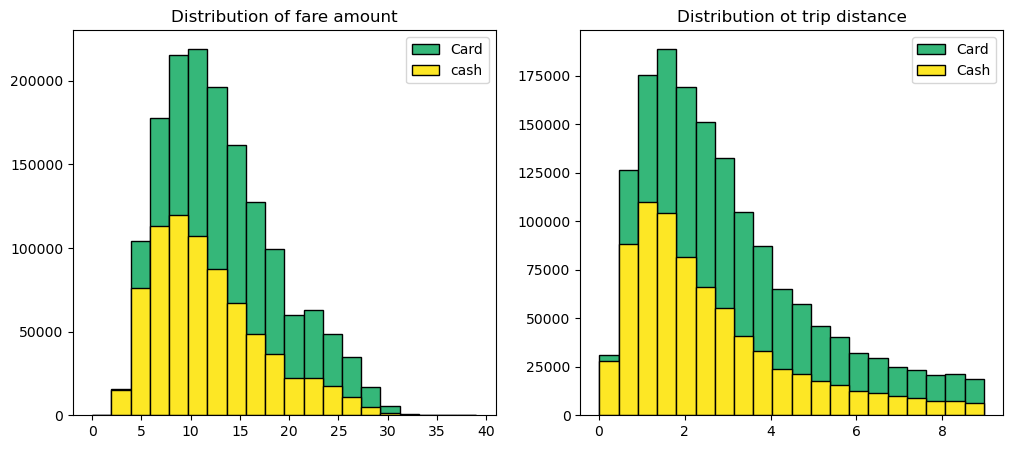

In [33]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.title("Distribution of fare amount")

plt.hist(df[df['payment_type']=='card']['fare_amount'], 
        histtype = 'barstacked',
        bins = 20,
        edgecolor = 'k',
        color = '#35B779',
        label = "Card")

plt.hist(df[df['payment_type']=='cash']['fare_amount'],
        histtype= 'barstacked',
        bins = 20,
        edgecolor = 'k',
        color = '#FDE725',
        label = 'cash')
plt.legend()

plt.subplot(1, 2, 2)
plt.title("Distribution ot trip distance")
card_df = df[df['payment_type'] == 'card']
cash_df = df[df['payment_type'] == 'cash']

plt.hist(card_df['trip_distance'], 
         color='#35B779', 
         bins=20, 
         edgecolor= 'k',
         label='Card')

plt.hist(cash_df['trip_distance'], 
         color='#FDE725', 
         bins= 20, 
         edgecolor = 'k',
         label='Cash')
plt.legend()


# Fare Amount                                                   
     Observation :
        Most fares are between 5–15.
        Right-skewed distribution.
        Card payments are more frequent.

    Business Insight: 
        Customers mostly take low-cost rides.
        Digital payments are widely used.

# Trip Distance

    Observation:
        Most trips are between 1–3 km.
        Right-skewed distribution.
        Card payments dominate across trip distances.
    
    Business Insight:
        Short-distance rides drive most of the business.
        Companies should optimize operations for frequent city trips.

In [34]:
df.groupby("payment_type").agg({
    'fare_amount':['mean', 'std'],
    'trip_distance':['mean', 'std']
})

fare_amount           trip_distance         
                    mean       std          mean      std
payment_type                                             
card           13.112493  5.849281      2.992237  1.99274
cash           11.758005  5.613038      2.602207  1.91372

# Payment Type performance
    Visualizing overall perference for card vs cash payment using a pie chart.

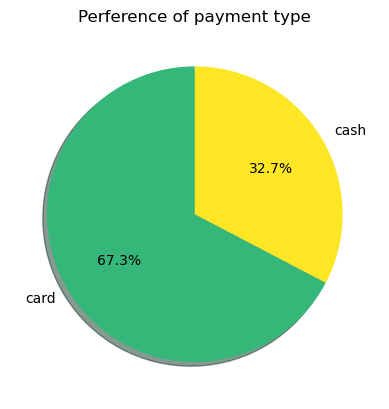

In [35]:
plt.title("Perference of payment type")
plt.pie(df['payment_type'].value_counts(normalize = True),
       labels = df['payment_type'].value_counts().index, 
       startangle = 90,
       shadow = True,
       autopct = '%1.1f%%',
       colors = ['#35B779', '#FDE725'])
plt.show()

# Observation

Most customers prefer to pay using a card rather than cash. Card payments account for approximately 67.3% of all transactions, while cash payments account for 32.7%.

# Passenger Count Analysis
Calculating passenger count distribution for each payment type and deriving percentages.

In [36]:
passenger_count = df.groupby(['payment_type', 'passenger_count',])[['passenger_count']].count()
passenger_count.rename(columns={'passenger_count': 'count'}, inplace = True)
passenger_count = passenger_count.reset_index()

In [37]:
passenger_count['perc']= (passenger_count['count']/passenger_count['count'].sum()) * 100

In [38]:
passenger_count

,payment_type,passenger_count,count,perc
0,card,1,909245,39.568381
1,card,2,327661,14.259100
2,card,3,122412,5.327106
3,card,4,63676,2.771042
4,card,5,124045,5.398171
5,cash,1,460550,20.042143
6,cash,2,155472,6.765806
7,cash,3,54506,2.371984
8,cash,4,32715,1.423686
9,cash,5,47626,2.072581


# Stacked Bar Visualization
Creating a stacked horizontal bar chart to visualize passenger count distribution by payment type.

In [39]:
pivot_df = pd.DataFrame(columns = ['payment_type', 1, 2, 3, 4, 5])
pivot_df['payment_type'] = ['card', 'cash']
pivot_df.iloc[0, 1:] = passenger_count.iloc[0:5, 1]
pivot_df.iloc[1, 1:] = passenger_count.iloc[5:, -1]

In [40]:
pivot_df

,payment_type,1,2,3,4,5
0,card,1,2,3,4,5
1,cash,20.042143,6.765806,2.371984,1.423686,2.072581


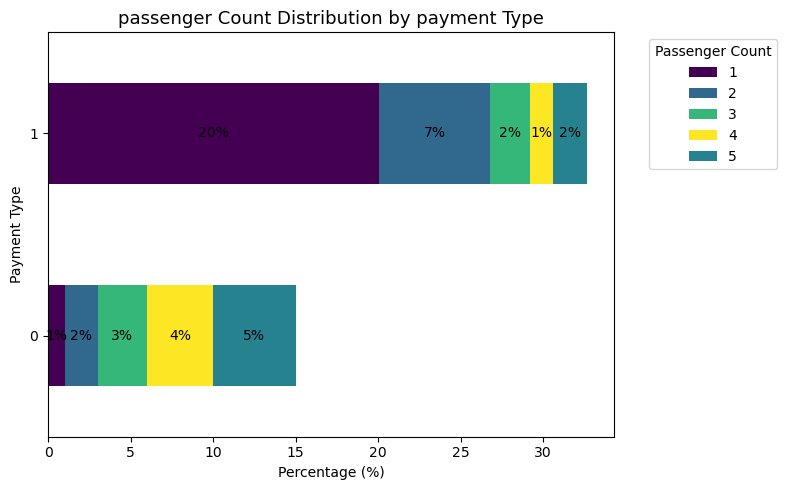

In [41]:
#1. creating horizontal bar plot.
ax = pivot_df.plot(
    kind = 'barh',
    stacked = True,
    color = ['#440154', '#31688E', '#35B779', '#FDE725', '#26828E'],
    figsize = (8, 5)
)

#2. Add percentage and labels
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        x, y = p.get_xy()
        ax.text(
            x + width/ 2,
            y + p.get_height()/2,
            f'{width:.0f}%',
            ha = 'center',
            va = 'center',
            fontsize = 10,
            color='black'
        )

#3. Add Titles and labels
plt.title('passenger Count Distribution by payment Type', fontsize=13)
plt.xlabel("Percentage (%)")
plt.ylabel("Payment Type")
plt.legend(title='Passenger Count', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [42]:
print(plt)
print(type(plt))
print(plt.xlabel)
print(type(plt.xlabel))

<module 'matplotlib.pyplot' from 'C:\\Users\\salau\\AppData\\Local\\anaconda3\\Lib\\site-packages\\matplotlib\\pyplot.py'>
<class 'module'>
<function xlabel at 0x000001B32DEDD300>
<class 'function'>


# Hypothesis Testing: Fare Amount
Performing a two single t-test to check if there is a significant difference in average fare amount between card and cash payment

In [43]:
pivot_df

,payment_type,1,2,3,4,5
0,card,1,2,3,4,5
1,cash,20.042143,6.765806,2.371984,1.423686,2.072581


In [47]:
card_sample = df[df['payment_type']=='card']['fare_amount']
cash_sample = df[df['payment_type']=='cash']['fare_amount']

In [51]:
t_stats, p_value = st.ttest_ind(a = card_sample, b = cash_sample, equal_var=False)
print("T Statistics", t_stats, "P Value", p_value)

T Statistics 169.2111527245052 P Value 0.0


# Hypothesis Test Interpretation

We performed a two-sample independent t-test to compare the average fare amounts between card and cash payments.

## Null Hypothesis (H₀):
There is no significant difference in the mean fare amount between card and cash payments.

## Alternative Hypothesis (H₁):
There is a significant difference in the mean fare amount between card and cash payments.

### Test Results:

    t-statistic: 169.21
    p-value: 0.0

## Conclusion:

Since the p-value (0.0) is less than the significance level of 0.05, we reject the null hypothesis. This provides strong statistical evidence that the average fare amount differs significantly between card and cash payment transactions in this dataset.

The analysis suggests a significant association between payment type and fare amount. However, the t-test alone does not establish that payment type causes the difference in fare amount.

# Regression Model
Implementing Regression model to explore relationship between trip duration and fare amount. 

#### Graphical representation for the relationship

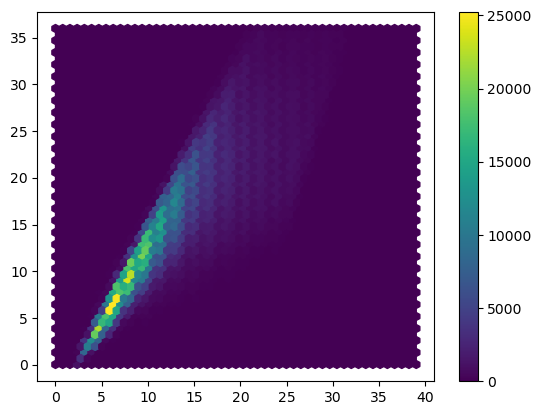

In [53]:
plt.hexbin(df['fare_amount'], df['duration'], gridsize=50)
plt.colorbar()

In [54]:
df[['fare_amount', 'duration']].corr()

,fare_amount,duration
fare_amount,1.000000,0.871877
duration,0.871877,1.000000


#### Data Splitting

In [56]:
from sklearn.model_selection import train_test_split

X = df[['duration']]
y = df['fare_amount']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### Building the model

In [57]:
from sklearn.linear_model import LinearRegression

In [58]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

#### Intercept and Coefficient

In [61]:
print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_[0])

Intercept: 2.5274212270978147
Coefficient: 0.6921463882817226


#### Evaluate the model

In [62]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

In [63]:
y_pred = model.predict(X_test)

In [66]:
print("R² Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R² Score: 0.7601103467039959
RMSE: 2.8498767851048092


R² Score tells us how much of the variation in the target variable (fare amount) is explained by the model using the input features.

The model explains approximately 76% of the variation in fare amount using the available feature(s) in the test dataset. The remaining 24% of the variation is due to factors that are not included in the model or due to random variation.

##### Graphical representation of actual and predicted values

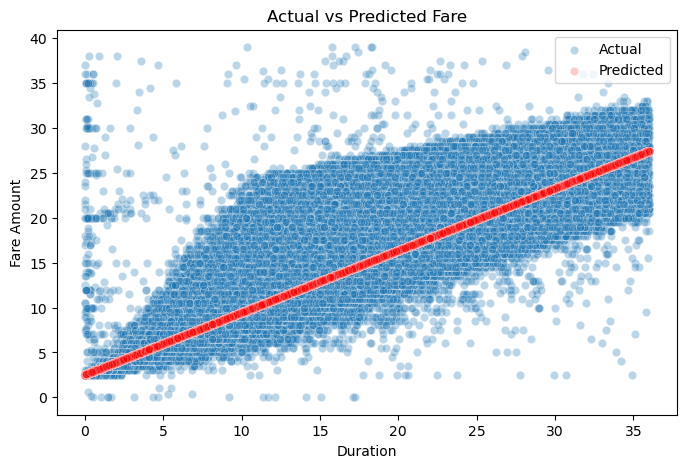

In [68]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plot_df = pd.DataFrame({
    "Duration": X_test.squeeze(),
    "Actual": y_test,
    "Predicted": y_pred
})

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=plot_df,
    x="Duration",
    y="Actual",
    alpha=0.3,
    label="Actual"
)

sns.scatterplot(
    data=plot_df,
    x="Duration",
    y="Predicted",
    color="red",
    alpha=0.2,
    label="Predicted"
)

plt.title("Actual vs Predicted Fare")
plt.xlabel("Duration")
plt.ylabel("Fare Amount")
plt.legend()
plt.show()